In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

# Load the dataset
df = pd.read_csv("85334965-5736-457a-b8d4-a077e6872f84 (1).csv")

# Clean missing values
df = df.dropna()

# Preview clean data
df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


--- Correlation with Sales ---
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Sales           1.000000
Name: Sales, dtype: float64


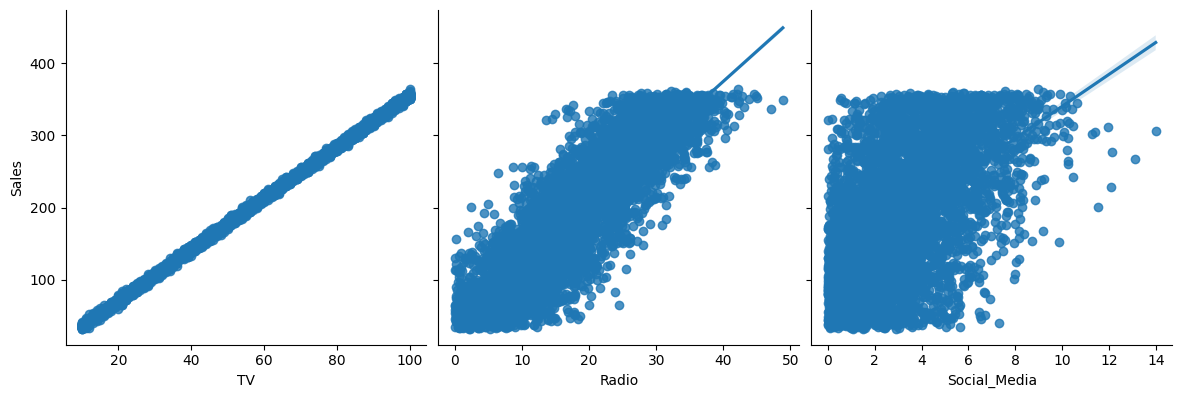

In [ ]:
# Calculate correlation matrix
correlation_matrix = df.corr()
print("--- Correlation with Sales ---")
print(correlation_matrix["Sales"])

# Visualize relationships
sns.pairplot(df, x_vars=["TV", "Radio", "Social_Media"], y_vars="Sales", height=4, aspect=1, kind="reg")
plt.show()

In [ ]:
# Define variables
X = df["TV"]
y = df["Sales"]
X = sm.add_constant(X)

# Fit OLS Model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:36:56   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

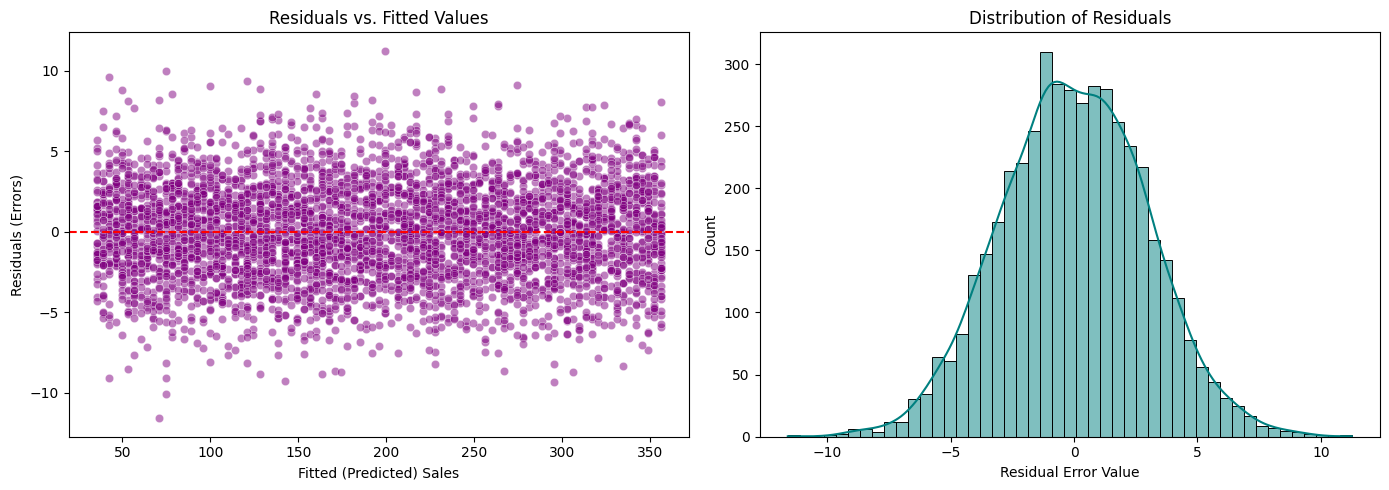

In [ ]:
# Extract fitted values and residuals
fitted_values = model.fittedvalues
residuals = model.resid

# Create diagnostic subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0], alpha=0.5, color="purple")
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals vs. Fitted Values')
axes[0].set_xlabel('Fitted (Predicted) Sales')
axes[0].set_ylabel('Residuals (Errors)')

# Normality distribution
sns.histplot(residuals, kde=True, ax=axes[1], color="teal")
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual Error Value')

plt.tight_layout()
plt.show()

## 🎯 Executive Summary & Marketing ROI Recommendation

### 1. Key Analytical Findings
* **The Winner:** **TV Advertising** has the absolute strongest relationship with Sales, boasting a near-perfect correlation coefficient of **0.9995**.
* **Model Accuracy:** Our Simple Linear Regression model reveals an **R-squared of 0.999**, meaning that **99.9% of all variance in Sales** is directly driven by TV ad spend.
* **Statistical Certainty:** The p-value for the TV metric is **0.000**, confirming that these results are highly statistically significant and not due to random chance.

### 2. Marketing ROI Interpretation (The Business Context)
* **TV Coefficient = 3.5615:** For every single dollar ($1.00) invested in TV advertising, the company generates an estimated **$3.56 in Sales**. This represents a massive, highly predictable positive Return on Investment (ROI).

### 3. Strategic Budget Allocation Recommendation
Based on this data-driven analysis, we recommend the following actions to the leadership team:
1. **Prioritize TV Spending:** Allocate the majority of the marketing budget to TV advertising, as it yields a clear, linear $3.56 return for every dollar spent.
2. **Optimize Secondary Channels:** While Radio has a strong correlation (0.86), it is heavily outmatched by TV. Social Media (0.52) should receive the lowest priority or be restructured, as it demonstrates the weakest link to overall Sales volume.